# 01 — Exploratory Data Analysis
**PanganTrace AI** — Analisis Transaksi Rantai Pasok Pangan

Notebook ini melakukan EDA pada data sintetik transaksi dan harga komoditas.

In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
%matplotlib inline

## 1. Load Data

In [2]:
# Generate synthetic data first
import sys; sys.path.insert(0, '../data/synthetic')
from generate_prices import generate_prices
from generate_transactions import generate_transactions

prices_path = generate_prices(days=90, output_dir='../data/synthetic')
tx_path = generate_transactions(days=90, output_dir='../data/synthetic')

df_prices = pd.read_csv(prices_path)
df_tx = pd.read_csv(tx_path)
print(f'Prices: {len(df_prices)} rows, Transactions: {len(df_tx)} rows')

Generated 8100 price records (247 anomalies, 3.0%) -> ../data/synthetic\prices.csv
✅ Generated 3696 transactions → ../data/synthetic\transactions.csv
Prices: 8100 rows, Transactions: 3696 rows


## 2. Distribusi Harga per Komoditas

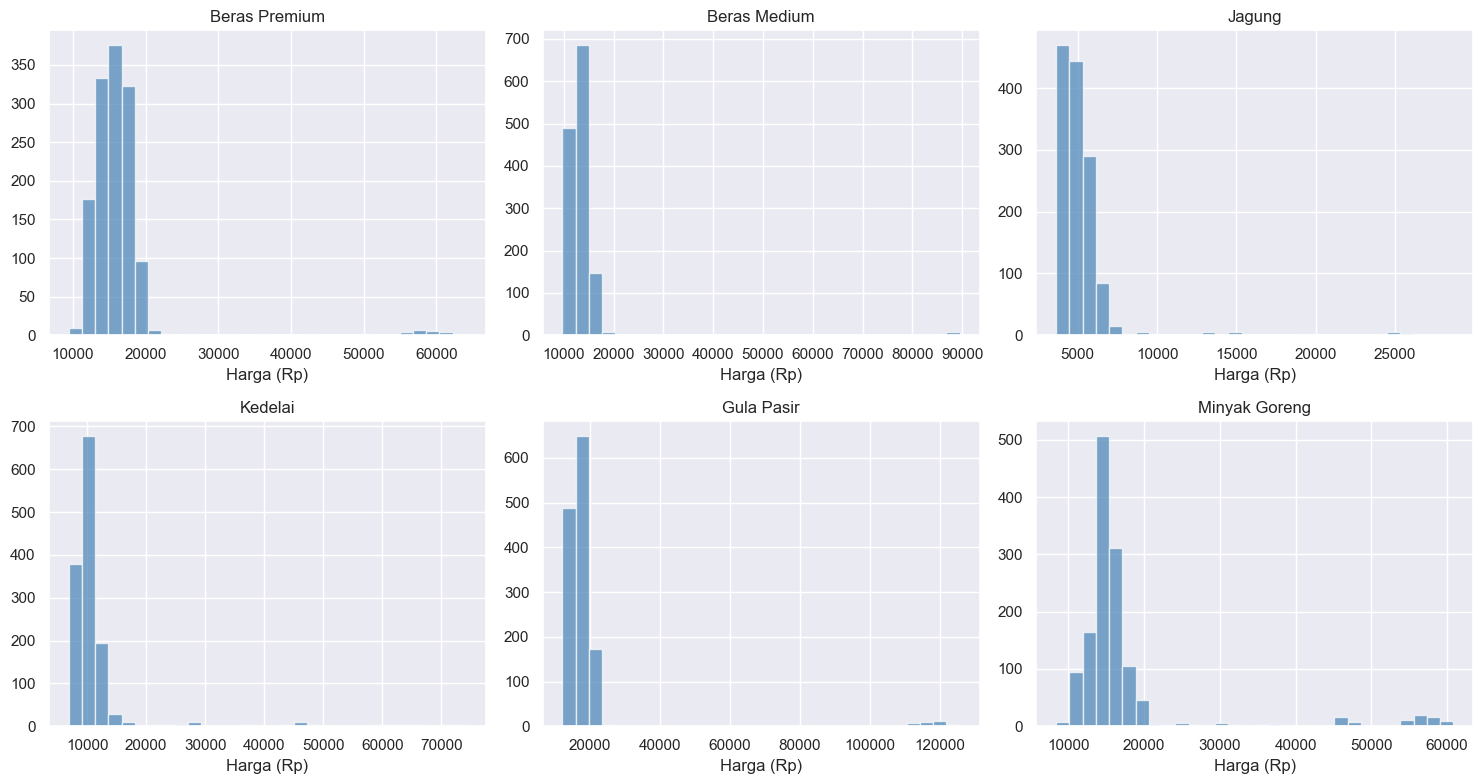

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, commodity in zip(axes.flat, df_prices['commodity_id'].unique()):
    subset = df_prices[df_prices['commodity_id'] == commodity]
    ax.hist(subset['price'], bins=30, alpha=0.7, color='steelblue')
    ax.set_title(commodity.replace('_', ' ').title())
    ax.set_xlabel('Harga (Rp)')
plt.tight_layout()
plt.savefig('../data/eda_price_distribution.png', dpi=150)
plt.show()

## 3. Time Series Harga

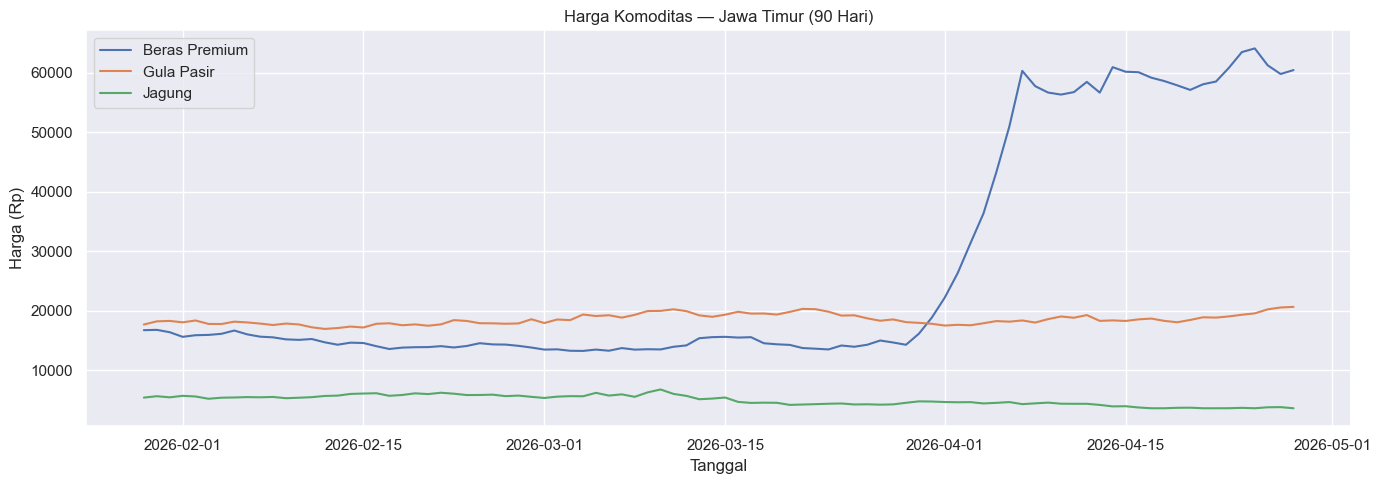

In [4]:
df_prices['recorded_at'] = pd.to_datetime(df_prices['recorded_at'])

fig, ax = plt.subplots(figsize=(14, 5))
for commodity in ['beras_premium', 'gula_pasir', 'jagung']:
    subset = df_prices[(df_prices['commodity_id'] == commodity) & (df_prices['province'] == 'Jawa Timur')]
    ax.plot(subset['recorded_at'], subset['price'], label=commodity.replace('_',' ').title(), linewidth=1.5)
ax.set_title('Harga Komoditas — Jawa Timur (90 Hari)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Harga (Rp)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Volume Discrepancy Analysis

In [5]:
vol_out = df_tx.groupby('from_node_id')['volume'].sum().reset_index()
vol_out.columns = ['node_id', 'volume_out']
vol_in = df_tx.groupby('to_node_id')['volume'].sum().reset_index()
vol_in.columns = ['node_id', 'volume_in']

chain = vol_out.merge(vol_in, on='node_id', how='outer').fillna(0)
chain['discrepancy_pct'] = ((chain['volume_in'] - chain['volume_out']) / chain['volume_in'].replace(0,1) * 100).round(2)

print('=== Nodes with discrepancy > 5% ===')
print(chain[chain['discrepancy_pct'].abs() > 5][['node_id','volume_in','volume_out','discrepancy_pct']])

=== Nodes with discrepancy > 5% ===
        node_id  volume_in  volume_out  discrepancy_pct
0   DIST-JB-001    20275.8     17781.6             12.3
1   DIST-JT-001    20549.3     19398.4              5.6
3   DIST-NT-001    20363.6     17593.3             13.6
4   PROD-JB-001        0.0     20275.8       -2027580.0
5   PROD-JT-001        0.0     13059.1       -1305910.0
6   PROD-JT-002        0.0     13749.9       -1374990.0
7   PROD-JT-003        0.0     14496.9       -1449690.0
8   PROD-NT-001        0.0     20363.6       -2036360.0
9    RET-JB-005    17781.6         0.0            100.0
10   RET-JT-012    19754.9         0.0            100.0
11   RET-JT-015    20190.4         0.0            100.0
12   RET-NT-003    17593.3         0.0            100.0


## 5. Correlation Matrix

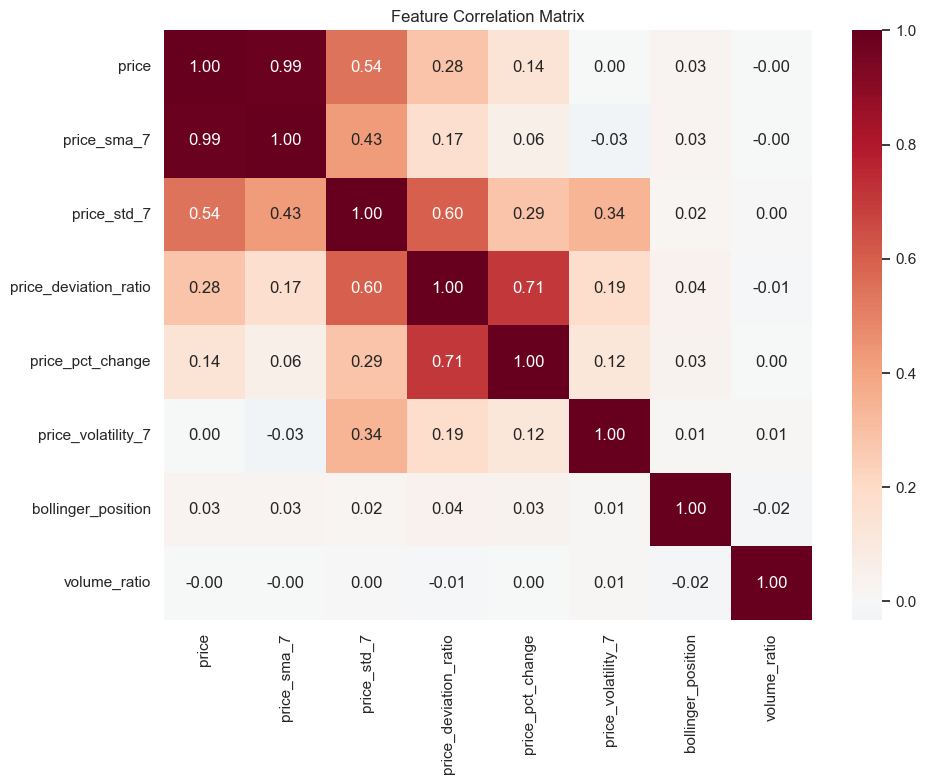


Total ground-truth anomalies: 247 (3.0%)


In [6]:
sys.path.insert(0, '../src')
from feature_engineering import compute_price_features

df_feat = compute_price_features(df_prices)
numeric_cols = [
    'price', 'price_sma_7', 'price_std_7', 
    'price_deviation_ratio', 'price_pct_change', 
    'price_volatility_7', 'bollinger_position', 'volume_ratio'
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_feat[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/eda_correlation_matrix.png', dpi=150)
plt.show()

print(f'\nTotal ground-truth anomalies: {df_prices["is_anomaly"].sum()} ({df_prices["is_anomaly"].mean()*100:.1f}%)')
